# BT4221 Project Group 4 — Spark EDA & Cleaning

**Note:** This notebook performs Exploratory Data Analysis with the raw `US_Accidents_March23.csv` file downloaded from Kaggle.  
The raw CSV or converted `US_Accidents_March23.parquet` parquet **must** be available in your local directory to successfully run this notebook.

## Problem Statement and Class Definition

Traffic congestion and road safety are critical issues for urban planning and emergency response management. This project leverages a countrywide dataset of US traffic accidents, spanning 49 states and collected via real-time traffic APIs from 2016 to 2023. The primary objective is to determine whether the severity of an accident, gauged by its impact on traffic flow, can be accurately predicted using real-time environmental, temporal, and spatial conditions.

The original dataset records accident severity on a scale from 1 to 4 of increasing traffic delay. The following notebook illustrates the Exploratory Data Analysis on 4 severity classes, cleaning, and preprocessing steps executed on the dataset before the data enters the automated data pipeline executed by LLM agents.

In [12]:
# Visual helper function (Only for printing purposes)  
def border(s):
    print(f"{'='*20} {s} {'='*20}")


## Environment Setup

### Google Colab
Run if you are using Google Colab

In [13]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [14]:
# Download and install Spark
border("Install dependencies")
!pip3 install pyspark

# Install findspark
!pip3 install findspark

# Initialise findspark
import findspark
findspark.init()

# Set java version
import os
# java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# os.environ['JAVA_HOME'] = java_path

# Verify installation
border("PySpark Version")
!pip show pyspark
border("findspark Version")
!pip show findspark
border("Hadoop version")
!hadoop version
border("Java version")
!java -version

==================== Install dependencies ====================
==================== PySpark Version ====================
Name: pyspark
Version: 4.1.1
Summary: Apache Spark Python API
Home-page: https://github.com/apache/spark/tree/master/python
Author: Spark Developers
Author-email: dev@spark.apache.org
License: Apache-2.0
Location: C:\Users\iiank\anaconda3\envs\spark_env\Lib\site-packages
Requires: py4j
Required-by: 
==================== findspark Version ====================
Name: findspark
Version: 2.0.1
Summary: Find pyspark to make it importable.
Home-page: https://github.com/minrk/findspark
Author: Min RK
Author-email: benjaminrk@gmail.com
License: BSD (3-clause)
Location: C:\Users\iiank\anaconda3\envs\spark_env\Lib\site-packages
Requires: 
Required-by: 
==================== Hadoop version ====================
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on pla

openjdk version "17.0.0.1" 2024-07-02
OpenJDK Runtime Environment (build 17.0.0.1+2-3)
OpenJDK 64-Bit Server VM (build 17.0.0.1+2-3, mixed mode, sharing)


## Import Libraries

In [15]:
# Import required libraries
from pyspark.sql import SparkSession

import pyspark.sql.functions as F

from pyspark.sql.types import NumericType

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

from pathlib import Path
import psutil
import os

# Visulisations only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Initialise SparkSession

### Dynamic SparkSession Configuration

In [16]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 12
Driver Memory: 11g


### Convert CSV file into Parquet (RUN ONCE)

In [17]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BT4221_Group4")
    .config("spark.driver.memory", driver_memory)
    .config("spark.sql.shuffle.partitions", cores * 3)
    .config("spark.default.parallelism", cores)
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_CSV_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23.csv"

if not ORIGINAL_CSV_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {ORIGINAL_CSV_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original CSV:", ORIGINAL_CSV_PATH)

# Read csv
df = spark.read.csv(str(ORIGINAL_CSV_PATH), header=True, inferSchema=True)

# Set parquet path
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23_parquet"

# Create directory if it doesn't exist
ORIGINAL_PARQUET_PATH.mkdir(parents=True, exist_ok=True)

# Write to parquet path
df.write.mode("overwrite").parquet(str(ORIGINAL_PARQUET_PATH))

print("Original Parquet:", ORIGINAL_PARQUET_PATH)

spark.stop()

Existing Spark session stopped.
App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original CSV: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23.csv
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23_parquet


### Read Parquet

In [18]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BT4221_Group4")
    .config("spark.driver.memory", driver_memory)
    .config("spark.sql.shuffle.partitions", cores * 3)
    .config("spark.default.parallelism", cores)
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset" / "US_Accidents_March23_parquet"

if not ORIGINAL_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original Parquet not found at: {ORIGINAL_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", ORIGINAL_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(ORIGINAL_PARQUET_PATH))

# Print metrics
border("Schema")
df.printSchema()

print()
border("First 5 rows")
df.show(5)

print()
border("Number of rows")
row_count = df.count()
print(row_count)

border("Number of columns")
col_count = df.columns
print(len(col_count))

Existing Spark session stopped.
App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23_parquet
==================== Schema ====================
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-

## Check for Missing Values

In [19]:
# Check for missing values across all datasets
def check_missing(df_name, df):
    missing_exprs = []
    for field in df.schema.fields:
        if isinstance(field.dataType, NumericType):
            expr = F.sum((F.col(field.name).isNull() | F.isnan(F.col(field.name))).cast("int")).alias(field.name)
        else:
            expr = F.sum(F.col(field.name).isNull().cast("int")).alias(field.name)
        missing_exprs.append(expr)
    missing_counts = df.select(*missing_exprs)

    border(f"Missing values in {df_name}")
    missing_counts.show()

check_missing("df", df)

==================== Missing values in df ====================
+---+------+--------+----------+--------+---------+---------+-------+-------+------------+-----------+------+----+------+-----+-------+-------+--------+------------+-----------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Source|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|End_Lat|End_Lng|Distance(mi)|Description|Street|City|County|State|Zipcode|Country|Timezone|Airport_Code|Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_

The initial assessment of the dataset reveals significant variation in data completeness across numerous features.

*   **Geospatial**: `End_Lat` and `End_Lng` columns are missing over 3.4 million entries, which accounts for approximately half the dataset.
*   **Environmental**: Weather-related features show a high frequency of null values, such as `Wind_Chill(F)` with ~2mil missing or `Precipitation(in)` with ~2.2mil missing.
*   **Twilight**: The available twilight markers show a consistent but relatively low number of missing values.

This profile highlights the need for a localised imputation strategy (using `Airport_Code` and  `Month`) to recover as much important environmental context as possible before modeling.

### Drop ID Column

In [20]:
df = df.drop("ID")

The `ID` acts as a unique surrogate key assigned by the data aggregator. To enable duplicate detection, `ID` is dropped so we may later perform a row-wise comparison.
Furthermore, `ID` carries no predictive power and only serves as a label. This does not contribute to our machine learning context.

## Check for Target Variable Imbalance

==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  67366|   0.87167|
|       2|6156981|  79.66702|
|       3|1299337|  16.81251|
|       4| 204710|    2.6488|
+--------+-------+----------+

==================== Barplot ====================


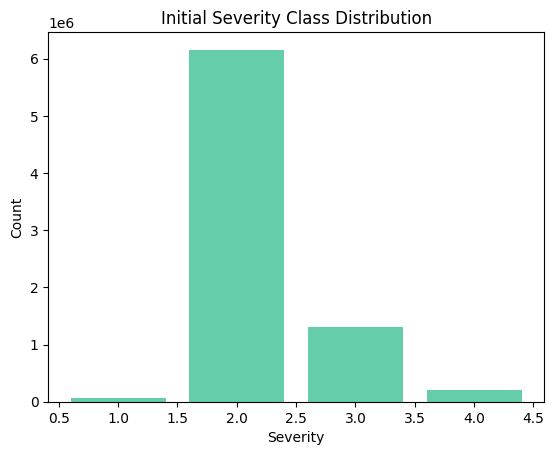

In [21]:
# Checking imbalance in Severity classes
def check_imbalance(df):
    severity_df = df.groupBy("Severity").agg(F.count("*").alias("Count"))

    total_count = severity_df.agg(F.sum("Count")).collect()[0][0]

    severity_df = severity_df.withColumn(
        "Percentage",
        F.round(F.col("Count") / total_count * 100, 5)
        ).orderBy("Severity")

    border("Checking for imbalance")

    # Table
    print()
    border("Table")
    severity_df.show()

    # Barplot
    severity_pd = severity_df.toPandas()
    border("Barplot")
    plt.figure()
    plt.title("Initial Severity Class Distribution")
    plt.bar(severity_pd["Severity"], severity_pd["Count"], color="mediumaquamarine")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.show()

check_imbalance(df)

The severity distribution reveals a significant class imbalance. Class 2 accounts for nearly 80 percent of all records, while Class 1 and 4 represent less than 1 percent and 3 percent respectively. This skew suggests that the majority of reported accidents have a moderate impact on traffic.

Since machine learning models often struggle to predict rare classes accurately, this imbalance justifies the grouping of severity levels into a binary classification. Furthermore, this suggests the need for using oversampling or undersampling during preprocessing.

## Check for Duplicates

In [22]:
intital_count = df.count()
df = df.dropDuplicates()
dupe_count = intital_count - df.count()
print(f"Number of duplicate rows dropped: {dupe_count}")

Number of duplicate rows dropped: 117695


The 117,695 duplicate rows may have arisen from overlapping reports by different traffic APIs. If left in the dataset, the model may overfit on specific recurring incidents and the duplicate records would skew group-based imputation by inflating the frequency of certain groups, which biases the aggregated values used to fill missing data. As such, the duplicate records are removed to preserve the statistical integrity of both the imputation step and the final analysis.

## Drop Columns

In [23]:
# Checking for Columns to drop
border("Country and Turning_Loop")
tbl = df.groupBy("Country", "Turning_Loop").count()
tbl.show()

border("Source column")
tbl = df.groupBy("Source").count()
tbl.show()

==================== Country and Turning_Loop ====================
+-------+------------+-------+
|Country|Turning_Loop|  count|
+-------+------------+-------+
|     US|       false|7610699|
+-------+------------+-------+

==================== Source column ====================
+-------+-------+
| Source|  count|
+-------+-------+
|Source2|3303245|
|Source1|4210136|
|Source3|  97318|
+-------+-------+



The `Country` column is slated for removal because it contains a single constant string of "US". The feature has zero variance and provides no information to help differentiate between classes.

Similarly, `Turning_Loop` is dropped due to its lack of variability, indicating that no turning loop was ever present in any accident record.

The `Source` column indicates which data provider or API supplied the record. This metadeta does not describe the physical or environmental conditions of the traffic accident, and so is dropped.

The `Description` column contains human provided descriptions of the accident that reiterate information contained within other columns, such as `Street`. Furthermore, it contains unstructured and high-dimensional data that is computationally expensive to process. As such, we have chosen to drop it.

In [24]:
temp_df = df.select("Wind_Chill(F)", "Temperature(F)").dropna()
corr_val = temp_df.stat.corr("Wind_Chill(F)", "Temperature(F)")
print(f"Correlation between Wind_Chill(F) and Temperature(F): {round(corr_val, 4)}")

Correlation between Wind_Chill(F) and Temperature(F): 0.9938


To reduce multicollinearity, the highly correlated `Wind_Chill(F)` with `Temperature(F)` (0.9937) will be dropped.

### `End_Lat` and `End_Lng`

#### `Start_Lat`, `Start_Lng`, `End_Lat` and `End_Lng`

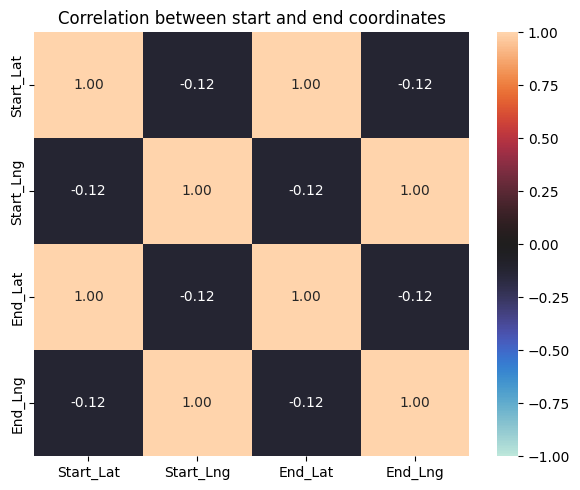

In [25]:
coord_features = ["Start_Lat", "Start_Lng", "End_Lat", "End_Lng"]
assembler = VectorAssembler(inputCols=coord_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df)

corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()
corr_pd = pd.DataFrame(corr_matrix, index=coord_features, columns=coord_features)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pd, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Correlation between start and end coordinates")
plt.tight_layout()
plt.show()

Each `Start_Lat` and `End_Lat`, `Start_Lng` and `End_Lng` pair of columns is highly correlated (1.00) within its respective pair. To reduce multicollinearity, we will keep `Start_Lat` and `Start_Lng` and drop `End_Lat`, and `End_Lng`.

### Drop in Pyspark

Due to the reasons above, we have chosen to drop columns `Country`, `Turning_Loop`, `Source`, `End_Lat`, `End_Lng`, `Description`, `Wind_Chill(F)`.

We will print the DataFrame schema again to verify the columns have been correctly dropped.

In [26]:
cols_to_drop = ["ID", "Country", "Turning_Loop", "Source", "End_Lat", "End_Lng", "Description", "Wind_Chill(F)"]
df = df.drop(*cols_to_drop)

border("After dropping")
df.printSchema()

==================== After dropping ====================
root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullab

## Check `Distance(mi)` Distribution

#### Distribution of `Distance(mi)`

==================== Distance distribution graph ====================


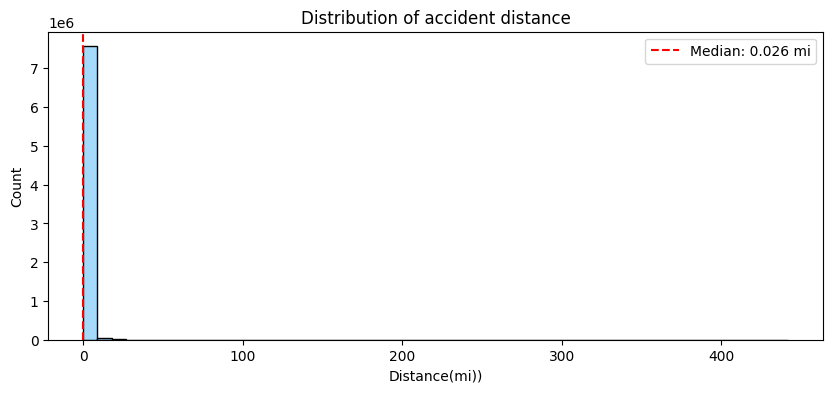

==================== Distance distribution table ====================
+------+------+
|  mean|median|
+------+------+
|0.5575| 0.026|
+------+------+



In [27]:
dist_pd = df.select("Distance(mi)").toPandas()
border("Distance distribution graph")
plt.figure(figsize=(10, 4))
sns.histplot(data=dist_pd, x="Distance(mi)", bins=50, color="lightskyblue")
plt.axvline(dist_pd["Distance(mi)"].median(), color="red", linestyle="--", label=f'Median: {dist_pd["Distance(mi)"].median():.3f} mi')
plt.xlabel("Distance(mi))")
plt.ylabel("Count")
plt.title("Distribution of accident distance")
plt.legend()
plt.show()

border("Distance distribution table")
df.select(
    F.round(F.mean("Distance(mi)"), 4).alias("mean"),
    F.round(F.median("Distance(mi)"), 4).alias("median")
).show()

The barplot reveals that a majority of `Distance(mi)` values fall below 20 miles, with a 0.5618 mean and 0.03 median.  
This suggests that later stages in the pipeline should consider the use of `StandardScaler` to normalise the feature.

#### Remove Outliers from `Distance(mi)`

Filter for Validity: `Distance(mi)` < 20mi  
A majority of `Distance(mi)` fall below 20 miles from the barplot. Furthermore, records with a continuous 20-mile disruption or higher are extremely unlikely to occur from a single traffic accident, and are more likely due to incorrect coordinate logging. As such, these records will be dropped to maintain spatial data quality.

In [28]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Distance(mi)") < 20)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)


==================== BEFORE ====================
7610699
==================== AFTER ====================
7602816

Rows dropped: 7883


## Process Time-based Features

### Process Start_Time & End_Time Columns

In [29]:
# Standardise Timestamp
df = (
    df.withColumn("Start_Time", F.to_timestamp(F.col("Start_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("End_Time", F.to_timestamp(F.col("End_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("Weather_Timestamp", F.to_timestamp(F.col("Weather_Timestamp"), "yyyy-MM-dd HH:mm:ss"))
)

# Extract: year, month, day_of_week, hour, is_weekend
df = df.withColumns({
    "Start_Time_Year": F.year(F.col("Start_Time")),
    "Start_Time_Month": F.month(F.col("Start_Time")),
    "Start_Time_Day_of_Week": F.dayofweek(F.col("Start_Time")),
    "Start_Time_Hour": F.hour(F.col("Start_Time")),
    "Start_Time_is_Weekend": F.when(F.col("Start_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0),
    "End_Time_Year": F.year(F.col("End_Time")),
    "End_Time_Month": F.month(F.col("End_Time")),
    "End_Time_Day_of_Week": F.dayofweek(F.col("End_Time")),
    "End_Time_Hour": F.hour(F.col("End_Time")),
    "End_Time_is_Weekend": F.when(F.col("End_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0)
})

### Drop Weather_Timestamps

In [30]:
mean_diff = df.select(
    F.mean((F.col("Weather_Timestamp").cast("long") - F.col("Start_Time").cast("long"))).alias("mean_diff_seconds")
).collect()[0]["mean_diff_seconds"]

print(f"Mean difference between 'Start_Time' and 'Weather_Timestamp': {mean_diff} seconds")

Mean difference between 'Start_Time' and 'Weather_Timestamp': 29.57593357614651 seconds


Since the mean difference between "Start_Time" and "Weather_Timestamp" is barely noticeable, we chose to drop "Weather_Timestamp" and keep Start_Time to Create Time-based features.

In [31]:
df = df.drop("Weather_Timestamp")

### Create & Process Duration Column

In [32]:
df = df.withColumns({
    "Duration_Seconds": F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time")),
    "Duration_Minutes": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 60,
    "Duration_Hours": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 3600
})

df.show(5)

+--------+-------------------+-------------------+------------------+-----------------+------------+--------------------+-----------+--------------+-----+----------+----------+------------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+------------------+------------------+
|Severity|         Start_Time|           End_Time|         Start_Lat|        Start_Lng|Distance(mi)|              Street|       City|        County|State|   Zipcode|  Timezone|Airport_Code|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mp

### Filter Duration Based on a Set Threshold

In [33]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Duration_Minutes") > 5.0) &
    (F.col("Duration_Hours") <= 288.0)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)

==================== BEFORE ====================
7602816
==================== AFTER ====================
7597533

Rows dropped: 5283


Filter for Validity: 5 mins < `Duration` <= 288 hours (12 days)  
Accidents lasting less than five minutes may be noise, such as extremely minor stalls or transient traffic sensor glitches. Accidents lasting more than 288 hours are statistically improbable to occur. Instead, these entires may represent long-term roadwork or seasonal closures instead of individual traffic incidents. As such, this filter is applied on `Duration` to refine the focus of the dataset on actual traffic incidents and reduce noise.

### Plot Accident Counts by Time-based Features (Grouped by Severity)

In [34]:
# unique_severity = [row["Severity"] for row in df.select("Severity").distinct().collect()]

In [35]:
# for severity in sorted(unique_severity):
#     filtered_df = df.filter(F.col("Severity") == severity)
#     total = filtered_df.count()
    
#     fig, axes = plt.subplots(2, 2, figsize=(16, 10))
#     fig.suptitle(f"Distribution of Severity {severity} Accidents", fontsize=16)
#     axes = axes.flatten()

#     plot_configs = [
#             ("Start_Time_Year", "Year"),
#             ("Start_Time_Month", "Month"),
#             ("Start_Time_Hour", "Hour"),
#             ("Start_Time_is_Weekend", "Weekend")
#         ]
        
#     for i, (col_name, label) in enumerate(plot_configs):
#         grouped = filtered_df.groupBy(col_name).count() \
#             .withColumn("pct", F.col("count") / total * 100) \
#             .orderBy(col_name).toPandas()
        
#         sns.barplot(ax=axes[i], data=grouped, x=col_name, y="pct", palette="viridis", hue=col_name)
#         axes[i].set_xlabel(label)
#         axes[i].set_ylabel("Percentage (%)")
#         axes[i].set_title(f"By {label}")
        
#     plt.show()

Since data was collected from February 2016 to March 2023, we can expect to see significantly lower counts for accidents in 2023 when aggregating by Year in subsequent visualisations.

* By Year
    * Severity 2 and 4 appear to have similar distributions of a steady increase over time
    * Severity 1 accidents are skewed significantly in 2020 and 2022
    * Severity 3 has its highest relative percentage in 2018
* By Month
    * Severity 1 is the only category that peaks significantly in May and June and is virtually non-existent in October to December
    * Severity 4 is most frequent in January and December. This suggests that winter weather may influence higher severity incidents.
    * Severity 2 and 3 show a relatively balanced distribution throughout the entire year.
* By Hour
    * Severity 1 accidents are heavily concentrated during the morning rush hour (0700 - 0800)
    * Severity 2 and 3 show M-shaped distributions with clear peaks in the morning and evening rush hours (1500 - 1800)
    * Severity 4 maintains a higher percentage of accidents during early-morning and late-night hours (0000 - 0400)
* By Weekend
    * There is a clear linear trend between accident severity and weekend occurrence:
        * Severity 1: ~7%
        * Severity 2: ~15%
        * Severity 3: ~17%
        * Severity 4: ~22%

### Plot Accident Counts by Time-based Features (Not grouped by Severity)

In [36]:
# def get_grouped_data(df, columns):
#     """Groups Spark DataFrame by specified columns and converts to Pandas."""
#     return df.groupBy(columns).count().toPandas()

# def plot_accident_count(data, x_col, hue=None, title=None):
#     """Function to create bar plots for accident counts."""
#     border(f"{title or x_col}")
    
#     plt.figure(figsize=(12, 6))
#     sns.barplot(data=data, x=x_col, y="count", palette="viridis", hue=x_col)
    
#     plt.xlabel(x_col)
#     plt.ylabel("Accident Count")
#     plt.title(title or f"Accident Count by {x_col}")
    
#     if hue:
#         plt.legend(title=hue, loc="upper right")
    
#     plt.tight_layout()
#     plt.show()

# def plot_accident_heatmap(data, index_col, pivot_cols, value_col="count"):
#     """Creates a heatmap for Year, Month, and Hour distributions."""
#     border(f"Heatmap: {', '.join(pivot_cols)}")
    
#     pivot = data.pivot_table(
#         index=index_col,
#         columns=pivot_cols,
#         values=value_col,
#         fill_value=0
#     )
    
#     plt.figure(figsize=(16, 6))
#     sns.heatmap(pivot)
#     plt.title(f"Accident Count by {', '.join(pivot_cols)} and {index_col}")
#     plt.show()

In [37]:
# # Bar plots
# year_data = get_grouped_data(df, "Start_Time_Year")
# plot_accident_count(year_data, "Start_Time_Year")

# month_data = get_grouped_data(df, "Start_Time_Month")
# plot_accident_count(month_data, "Start_Time_Month")

# hour_data = get_grouped_data(df, "Start_Time_Hour")
# plot_accident_count(hour_data, "Start_Time_Hour")

# weekend_data = get_grouped_data(df, "Start_Time_is_Weekend")
# plot_accident_count(weekend_data, "Start_Time_is_Weekend")

# # Grouped Bar Plots
# year_month_data = get_grouped_data(df, ["Start_Time_Year", "Start_Time_Month"])
# plot_accident_count(year_month_data, "Start_Time_Year", hue="Start_Time_Month", 
#                     title="Accident Count by Year and Month")

# # Heatmap (Year, Month, and Hour)
# year_month_hour_data = get_grouped_data(df, ["Start_Time_Year", "Start_Time_Month", "Start_Time_Hour"])
# plot_accident_heatmap(year_month_hour_data, 
#                       index_col="Start_Time_Hour", 
#                       pivot_cols=["Start_Time_Year", "Start_Time_Month"])

Overall, there is an upward trend in accident counts from 2016 to 2022. While this may suggest an increase in accidents, it is more likely to indicate improved data collection coverage.

Other observations:
* There is a visible, sharp dip in accident counts in July and August 2020.
* Accident counts generally peak in the last quarter of the year (October to December), represented by the darkest bars in each yearly cluster.
* Accident counts tend to be lowest in the middle of the year and higher at the start and end, possibly due to winter driving conditions.
* The heatmap displays clear zones of high accident counts throughout the years:
    * Morning rush between 0700 and 0900
    * Evening rush between 1500 and 1800

## Standardise Wind_Direction

In [38]:
# Print all unique values and their counts in terms of dict
def get_count(df):
    counts_df = df.groupBy("Wind_Direction").agg(F.count("*").alias("count"))
    counts_dict = {row["Wind_Direction"]: row["count"] for row in counts_df.collect()}
    total_count = df.count()

    return counts_dict, total_count

before_dict, before_total = get_count(df)

border("BEFORE")
print(before_dict)
print("Total count:", before_total)

# Standardise into N, S, E, W, NE, SE, NW, SW, CALM, VAR
df = df.withColumn(
    "Wind_Direction",
    F.when(F.col("Wind_Direction") == "Calm", "CALM")
    .when(F.col("Wind_Direction").isin("North", "NNE", "NNW"), "N")
    .when(F.col("Wind_Direction").isin("East", "ENE", "ESE"), "E")
    .when(F.col("Wind_Direction").isin("South", "SSE", "SSW"), "S")
    .when(F.col("Wind_Direction").isin("West", "WNW", "WSW"), "W")
    .when(F.col("Wind_Direction") == "Variable", "VAR")
    .otherwise(F.col("Wind_Direction"))
)

# Drop remaining null values
df = df.dropna(subset="Wind_Direction")

after_dict, after_total = get_count(df)

print()
border("AFTER")
print(after_dict)
print("Total count:", after_total)
print("\nRow dropped:", before_total - after_total)

==================== BEFORE ====================
{'VAR': 246176, None: 170309, 'SSE': 343665, 'N': 299818, 'S': 411620, 'CALM': 937110, 'SE': 290147, 'West': 164157, 'ESE': 263869, 'South': 176830, 'WNW': 372428, 'SW': 359258, 'East': 103159, 'Calm': 367437, 'W': 376099, 'NNW': 327402, 'Variable': 113656, 'NNE': 250711, 'North': 152894, 'NW': 362705, 'WSW': 348667, 'E': 272316, 'SSW': 379201, 'NE': 254093, 'ENE': 253806}
Total count: 7597533

==================== AFTER ====================
{'VAR': 359832, 'N': 1030825, 'S': 1311316, 'CALM': 1304547, 'SE': 290147, 'SW': 359258, 'W': 1261351, 'NW': 362705, 'E': 893150, 'NE': 254093}
Total count: 7427224

Row dropped: 170309


The original `Wind_Direction` feature exhibits high cardinality with redundant labels such as "North" and "N" as well as hyper-specific sub-directions like North-Northeast "NNE". By merging synonymous terms and grouping third-degree directions into their second-degree parents, we simplify the feature space without losing meaningful meteorological context. This consolidation prevents the model from treating identical directions as distinct categories and reduces the risk of overfitting to specific wind angles that likely have a marginal impact on accident severity.

## Handle missing values

- Impute missing values for:
  1. Temperature(F)
  2. Humidity(%)
  3. Pressure(in)
  4. Visibility(mi)
  5. Wind_Speed(mph)
  6. Precipitation(in)

In [39]:
# Print missing values from weather data
def show_missing_weather(df, weather, label):
    border(label)
    df.select([
        F.sum((F.col(c).isNull() | F.isnan(F.col(c))).cast("int")).alias(c)
        for c in weather
    ]).show()

# Create list of weather data
weather = ["Temperature(F)","Humidity(%)","Pressure(in)","Visibility(mi)","Wind_Speed(mph)", "Precipitation(in)"]

show_missing_weather(df, weather, "BEFORE")

# Impute missing values with median based on Airport_Code and Start_Time_Month
median_df = df.groupBy("Airport_Code", "Start_Time_Month").agg(
    *[F.median(F.col(c)).alias(f"{c}_median") for c in weather]
)
df = df.join(median_df, on=["Airport_Code", "Start_Time_Month"], how="left")
for c in weather:
    df = df.withColumn(c, F.coalesce(F.col(c), F.col(f"{c}_median")))

df = df.drop(*[f"{c}_median" for c in weather])
df = df.dropna(subset=weather)

show_missing_weather(df, weather, "AFTER")

==================== BEFORE ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|         31944|      41830|       14665|         40698|         394901|          2071724|
+--------------+-----------+------------+--------------+---------------+-----------------+

==================== AFTER ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|             0|          0|           0|             0|              0|                0|
+--------------+-----------+------------+--------------+---------------+-----------

Weather conditions are intrinsically linked to specific geographic locations and seasonal cycles. Imputing missing numerical values using the **median** grouped by `Airport_Code` and `Start_Time_Month` ensures that the substituted data reflects the micro-climate of the area.

Since it is stated that traffic weather data is collected from airport-based sensors, using the `Airport_Code` provides the most accurate proxy for the local weather condition. Furthermore, incorporating the `Start_Time_Month` captures seasonal variations that a global imputation would overlook. Lastly, using the median within these specific groups provides a representative value that is resistant to extreme weather anomalies.

## Drop Remaining NA rows

We will proceed to drop NA values present in `City`, `Zipcode`, `Airport_Code`, `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, `Astronomical_Twilight` since the remaining missing values in these columns as previously identified are below 500000.

In [40]:
# Drop NA rows for City, Zipcode, Airport_Code, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight
bef_drop_n = df.count()
df = df.dropna(
    subset=['City', 'Zipcode', 'Airport_Code', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Street', 'Weather_Condition']
)
aft_drop_n = df.count()

print()
border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("Rows dropped:", bef_drop_n - aft_drop_n)


==================== BEFORE ====================
7264645
==================== AFTER ====================
7205297
Rows dropped: 59348


## Accident Counts by Severity for Categorical and Boolean Columns

### Accident Count by Severity Functions

In [41]:
# def get_percentage_data(filtered_df, column, total_count):
#     """Groups data by a column and calculates the percentage of total."""
#     return filtered_df.groupBy(column).count() \
#         .withColumn("pct", F.col("count") / total_count * 100) \
#         .toPandas()

# def plot_severity_dashboard(df, column_name, severities=unique_severity):
#     """Generates a 2x2 grid of plots for a specific column across 4 severities."""
#     column_name_str = column_name.replace('_', ' ')
#     fig, axes = plt.subplots(2, 2, figsize=(20, 12))
#     fig.suptitle(f"Accident Percentage by {column_name} Across Severities", fontsize=20)
#     axes = axes.flatten()

#     for i, severity in enumerate(sorted(severities)):
#         filtered_df = df.filter(F.col("Severity") == severity)
#         total = filtered_df.count()
        
#         pd_df = get_percentage_data(filtered_df, column_name, total)
        
#         sns.barplot(ax=axes[i], data=pd_df, x=column_name, y="pct", palette="viridis", hue=column_name)
#         axes[i].set_title(f"Severity {severity}")
#         axes[i].set_ylabel("Percentage (%)")
#         axes[i].set_xlabel(column_name_str)
#         axes[i].tick_params(axis='x', rotation=90)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()

### Accident Count by Severity by State

In [42]:
# plot_severity_dashboard(df, "State")

### Accident Count by Severity by Longitude and Latitude

In [43]:
# # Group by Longitude and Latitude
# for severity in sorted(unique_severity):
#     filtered_df = df.filter(F.col("Severity") == severity)
#     grouped_by_longitude_latitude = filtered_df.groupBy("Start_Lng", "Start_Lat").count().toPandas()

#     print()
#     border(f"Accident Count by Longitude and Latitude (Severity = {severity})")
#     plt.figure(figsize=(12, 6))
#     sns.scatterplot(data=grouped_by_longitude_latitude, x="Start_Lng", y="Start_Lat", size="count", sizes=(20, 200), legend=None)
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.title(f"Accident Count by Longitude and Latitude (Severity = {severity})")
#     plt.show()

### Accident Count by Severity by Weather Condition

In [44]:
# plot_severity_dashboard(df, "Weather_Condition")

### Accident Count by Severity by Wind Direction

In [45]:
# plot_severity_dashboard(df, "Wind_Direction")

### Accident Count by Severity by POI Features

In [46]:
# poi_columns = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]

# poi_rows = []
# for severity in sorted(unique_severity):
#     filtered_df = df.filter(F.col("Severity") == severity)
#     total = filtered_df.count()
#     row = {"Severity": severity}
#     for poi in poi_columns:
#         true_count = filtered_df.filter(F.col(poi) == True).count()
#         row[poi] = true_count / total * 100
#     poi_rows.append(row)

# import pandas as pd
# poi_pd = pd.DataFrame(poi_rows).set_index("Severity")

# plt.figure(figsize=(8, 4))
# sns.heatmap(poi_pd, annot=True, fmt=".1f", cmap="YlOrRd")
# plt.title("% of accidents near POI, by severity")
# plt.ylabel("Severity")
# plt.show()

As shown from the heatmap, the POI columns `Amenity`, `Bump`, `Give_Way`, `No_Exit`, `Railway`, `Roundabout`, and `Traffic_Calming` do not have a significant percentage of accidents occurring near the POI, nor show significant differentiation amongst the different severities. As such, we will drop these POI features.

### Accident Count by Severity by Twilight Features

In [47]:
# twilight_columns = ["Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]

# for feature in twilight_columns:
#     plot_severity_dashboard(df, feature)

## Drop Columns After Investigation

In [48]:
cols_to_drop = ["Amenity", "Bump", "Give_Way", "No_Exit", "Railway", "Roundabout", "Traffic_Calming"]
df = df.drop(*cols_to_drop)

We also choose to drop the columns `Duration_Minutes` and `Duration_Hours` before the dataset enters the Agent pipeline, as these columns are highly correlated with `Duration_Seconds`.

In [49]:
end_time_cols = [c for c in df.columns if c.startswith("End_Time")]
print("Dropping:", end_time_cols)
df = df.drop(*end_time_cols)

duration_cols = [c for c in df.columns if c.startswith("Duration")]
print("Dropping:", duration_cols)
df = df.drop(*duration_cols)

cols_to_drop = ["Distance(mi)"]
print("Dropping:", cols_to_drop)
df = df.drop(*cols_to_drop)

Dropping: ['End_Time', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend']
Dropping: ['Duration_Seconds', 'Duration_Minutes', 'Duration_Hours']
Dropping: ['Distance(mi)']


## Binarise Severity (Target Variable)

In [50]:
df = df.withColumn("high_severity", (F.col("Severity") >= 3).cast("int"))

## Check for Duplicates

In [51]:
final_count = df.count()
df = df.dropDuplicates(subset=["Start_Time", "Start_Lat", "Start_Lng", "Street"])
dupe_count = final_count - df.count()
print(f"Number of duplicate rows dropped: {dupe_count}")

Number of duplicate rows dropped: 397889


Following the full cleaning and imputation pipeline, a final duplicate check is performed on the natural key columns `Start_Time`, `Start_Lat`, `Start_Lng`, and `Street`. This step is critical as cleaning operations such as imputation and feature engineering can inadvertently introduce of surface new duplicates that were not present in the raw data. The 397,889 rows removed here reflect records that, after cleaning, became indistinguishable from one another across these key identifiers. Omitting this final check would allow these redundant records to propagate into model trainng, undermining the integrity of the dataset.

## End of Cleaning

### Check for Target Variable Imbalance

==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  61673|   0.90597|
|       2|5368318|  78.85994|
|       3|1222137|  17.95304|
|       4| 155280|   2.28104|
+--------+-------+----------+

==================== Barplot ====================


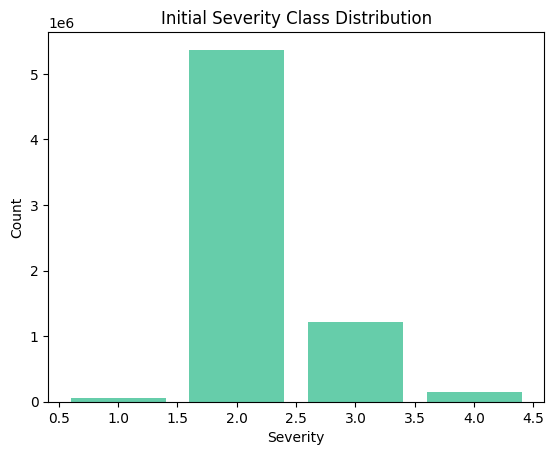

In [52]:
check_imbalance(df)

### Check for missing values

In [53]:
check_missing("df", df)

==================== Missing values in df ====================
+------------+----------------+--------+----------+---------+---------+------+----+------+-----+-------+--------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-------+----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+
|Airport_Code|Start_Time_Month|Severity|Start_Time|Start_Lat|Start_Lng|Street|City|County|State|Zipcode|Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction|Station|Stop|Traffic_Signal|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|Start_Time_Year|Start_Time_Day_of_Week|Start_Time_Hour|Start_Time_is_Weekend|high_severity|
+------------+----------------+--------+----------+

### Print Metrics

In [54]:
# Print metrics
border("Cleaned dataset schema")
df.printSchema()

print()
border("First 5 rows")
df.show(5)

print()
border("Number of rows")
row_count = df.count()
print(row_count)

border("Number of columns")
col_count = df.columns
print(len(col_count))

==================== Cleaned dataset schema ====================
root
 |-- Airport_Code: string (nullable = true)
 |-- Start_Time_Month: integer (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Crossing: boolean (nullable = true)
 |-- Junction: boolean (nullab

## Download Cleaned Data as Parquet

In [55]:
# Read directories
PROJECT_ROOT = Path.cwd().parent
OUTPUT_PARQUET_PATH = PROJECT_ROOT / "dataset" / "cleaned_parquet"
print("Project root:", PROJECT_ROOT)
print("Output parquet:", OUTPUT_PARQUET_PATH)

# Create directory if it doesn't exist
OUTPUT_PARQUET_PATH.mkdir(parents=True, exist_ok=True)

# Save parquet
df.write.mode("overwrite").parquet(str(OUTPUT_PARQUET_PATH))
print("Cleaned parquet successfully written!")

Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Output parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\cleaned_parquet
Cleaned parquet successfully written!


In [56]:
spark.stop()